# import

In [1]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm


# 乱数の固定

In [2]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True


# （可能なら）GPUの利用

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


# 汎用関数の定義

## func show_images_labels

In [17]:
# イメージとラベル表示
def show_images_labels(loader, classes, net, device):
    # データローダーから最初の1セットを取得する
    for images, labels in loader:
        break
    # 表示数は50個とバッチサイズのうち小さい方
    n_size = min(images.size(0), 50)

    if net is not None:
        # デバイスの割り当て
        inputs = images.to(device)
        labels = labels.to(device)

      # 予測計算
        outputs = net(inputs)
        predicted = torch.max(outputs,1)[1]
        #images = images.to('cpu')

    # 最初のn_size個の表示
    plt.figure(figsize=(20, 15))
    for i in range(n_size):
        ax = plt.subplot(5, 10, i + 1)
        label_name = classes[labels[i]]
        # netがNoneでない場合は、予測結果もタイトルに表示する
        if net is not None:
            predicted_name = classes[predicted[i]]
            # 正解かどうかで色分けをする
            if label_name == predicted_name:
                c = 'k'
            else:
                c = 'b'
            ax.set_title(label_name + ':' + predicted_name, c=c, fontsize=20)
        # netがNoneの場合は、正解ラベルのみ表示
        else:
            ax.set_title(label_name, fontsize=20)
        # TensorをNumPyに変換
        image_np = images[i].numpy().copy()
        print(image_np.shape)
        # 軸の順番変更 (channel, row, column) -> (row, column, channel)
        img = np.transpose(image_np, (1, 2, 0))
        # 値の範囲を[-1, 1] -> [0, 1]に戻す
        img = (img + 1)/2
        # 結果表示
        plt.imshow(img)
        ax.set_axis_off()
    plt.show()


## func evaluate_history

In [ ]:
def evaluate_history(history):
    print(f'初期状態: 損失: {history[0, 3]:.5f} 精度: {history[0, 4]:.5f}') 
    print(f'最終状態: 損失: {history[-1, 3]:.5f} 精度: {history[-1, 4]:.5f}' )

    num_epochs = len(history)
    unit = num_epochs / 10

    plt.figure(figsize=(9, 8))
    plt.plot(history[:, 0], history[:, 1], 'r', label='train')
    plt.plot(history[:, 0], history[:, 3], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Learning Curve (Loss)')
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(9,8))
    plt.plot(history[:, 0], history[:, 2], 'r', label='train')
    plt.plot(history[:, 0], history[:, 4], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Learning Curve (Accuracy)')
    plt.grid()
    plt.legend()
    plt.show()


# MLP
まずは，MLPでCIFAR-10に突撃してみる．

## データ準備

### Transformsの定義
データ範囲を$[0, 1]$から$[-1, 1]$へ変換したいものとする．
`Normalize(μ, σ)`は，元のデータ$x$を$X = (x - \mu) / \sigma$へ変換する．

In [ ]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5), # [0, 1] -> [-1, 1]
    transforms.Lambda(lambda x: x.view(-1))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5), # [0, 1] -> [-1, 1]
    transforms.Lambda(lambda x: x.view(-1))
])


### データセットの定義
Transformsを後から変更するのが危険なので，こんなまどろっこしい書き方をします．

In [7]:
data_root = './data'

# 初期化時にTransformsを設定した，元になるデータセットを作る．
train_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)
valid_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=eval_transform)

train_size = int(len(train_set_full) * 0.9)
valid_size = len(train_set_full) - train_size

# データを分割するためのランダムなインデックスを作成
indices = torch.randperm(len(train_set_full)).tolist()

train_set = Subset(train_set_full, indices[:train_size])
valid_set = Subset(valid_set_full, indices[train_size:])
test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=eval_transform)

print(len(train_set))
print(len(valid_set))
print(len(test_set))


100%|██████████| 170M/170M [00:04<00:00, 40.6MB/s] 


45000
5000
10000


### データセットの確認

In [8]:
image, label = train_set[0]
print("3 * 32 * 32 =", 3 * 32 * 32)
print(image.shape)
print(label)


3 * 32 * 32 = 3072
torch.Size([3072])
6


### データローダーの定義
データローダーを使うと，for文でミニバッチを取り出す事ができるよね．

In [9]:
batch_size = 100 # ミニバッチのサイズ指定

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# データローダーから先頭のミニバッチを取得してみる．
for loader in [train_loader, valid_loader, test_loader]:
    for images, labels in loader:
        print(f"images.shape: {images.shape}, labels.shape: {labels.shape}")
        break


images.shape: torch.Size([100, 3072]), labels.shape: torch.Size([100])
images.shape: torch.Size([100, 3072]), labels.shape: torch.Size([100])
images.shape: torch.Size([100, 3072]), labels.shape: torch.Size([100])


### 正解ラベルの変換規則

In [10]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## モデル定義
3072入力10出力1隠れ層のニューラルネットワークモデル

### 次元数の定義

In [ ]:
n_input = images[0].shape[0]
n_output = len(classes)
n_hidden = 128

print(n_input)
print(n_output)
print(n_hidden)


3072
10
128


### モデルのクラスを定義

In [12]:
class Net(nn.Module):
    def __init__(self, n_input, n_output, n_hidden):
        super().__init__()

        self.l1 = nn.Linear(n_input, n_hidden)
        self.l2 = nn.Linear(n_hidden, n_output)
        self.relu = nn.ReLU(inplace=True) # 中間テンソルを上書きしてメモリ節約

    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.relu(x1)
        x3 = self.l2(x2)
        return x3


## 学習

### 初期設定

In [13]:
num_epochs = 50

# 予測計算用
net = Net(n_input=n_input, n_output=n_output, n_hidden=n_hidden).to(device)

# 損失計算用
criterion = nn.CrossEntropyLoss()

# パラメータ更新用
lr = 0.01
optimizer = optim.SGD(params=net.parameters(), lr=lr)

# 記録用
history = np.zeros((0, 5)) # epoch, loss (train), acc (train), loss (valid), acc (valid)


### 学習ループ

In [14]:
for epoch in range(num_epochs):
    train_loss_sum, train_acc_sum, n_train = 0, 0, 0
    valid_loss_sum, valid_acc_sum, n_valid = 0, 0, 0

    # 訓練フェーズ
    net.train()
    for images, labels in tqdm(train_loader):
        batch_size = images.size(0)
        n_train += batch_size

        # GPUに送る．
        inputs = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 勾配の初期化
        outputs = net(inputs) # 予測計算
        loss = criterion(outputs, labels) # 損失計算
        loss.backward() # 勾配計算
        optimizer.step() # パラメータ更新

        # lossはバッチサイズで平均が取られているため平均前の損失に戻して加算
        train_loss_sum += loss.item() * batch_size
        values, indices = torch.max(outputs, dim=1)
        train_acc_sum += (indices == labels).sum().item()

    # 検証フェーズ
    net.eval()
    with torch.no_grad():
        for images, labels in valid_loader:
            batch_size = images.size(0)
            n_valid += batch_size

            # GPUに送る．
            inputs = images.to(device)
            labels = labels.to(device)

            outputs = net(inputs) # 予測計算
            loss = criterion(outputs, labels) # 損失計算

            # lossはバッチサイズで平均が取られているため平均前の損失に戻して加算
            valid_loss_sum += loss.item() * batch_size
            values, indices = torch.max(outputs, dim=1)
            valid_acc_sum += (indices == labels).sum().item()

    # 記録フェーズ
    train_loss = train_loss_sum / n_train
    train_acc = train_acc_sum / n_train

    valid_loss = valid_loss_sum / n_valid
    valid_acc = valid_acc_sum / n_valid

    print(f"epoch: {epoch}/{num_epochs}, train_loss: {train_loss}, train_acc: {train_acc}, valid_loss: {valid_loss}, valid_acc: {valid_acc}")
    item = np.array([epoch, train_loss, train_acc, valid_loss, valid_acc])
    history = np.vstack((history, item))


  0%|          | 0/450 [00:00<?, ?it/s]

epoch: 0/50, train_loss: 1.9573746630880569, train_acc: 0.3152888888888889, valid_loss: 1.816148521900177, valid_acc: 0.3722


  0%|          | 0/450 [00:00<?, ?it/s]

epoch: 1/50, train_loss: 1.750828451845381, train_acc: 0.3902888888888889, valid_loss: 1.713404266834259, valid_acc: 0.402


  0%|          | 0/450 [00:00<?, ?it/s]

...

epoch: 47/50, train_loss: 1.004340401755439, train_acc: 0.6613555555555556, valid_loss: 1.3637134981155397, valid_acc: 0.5228


  0%|          | 0/450 [00:00<?, ?it/s]

epoch: 48/50, train_loss: 0.9962725845972696, train_acc: 0.6642, valid_loss: 1.361801483631134, valid_acc: 0.5236


  0%|          | 0/450 [00:00<?, ?it/s]

epoch: 49/50, train_loss: 0.9879503095149994, train_acc: 0.6660888888888888, valid_loss: 1.3750856852531432, valid_acc: 0.5262


## 評価

初期状態: 損失: 1.81615 精度: 0.37220
最終状態: 損失: 1.37509 精度: 0.52620


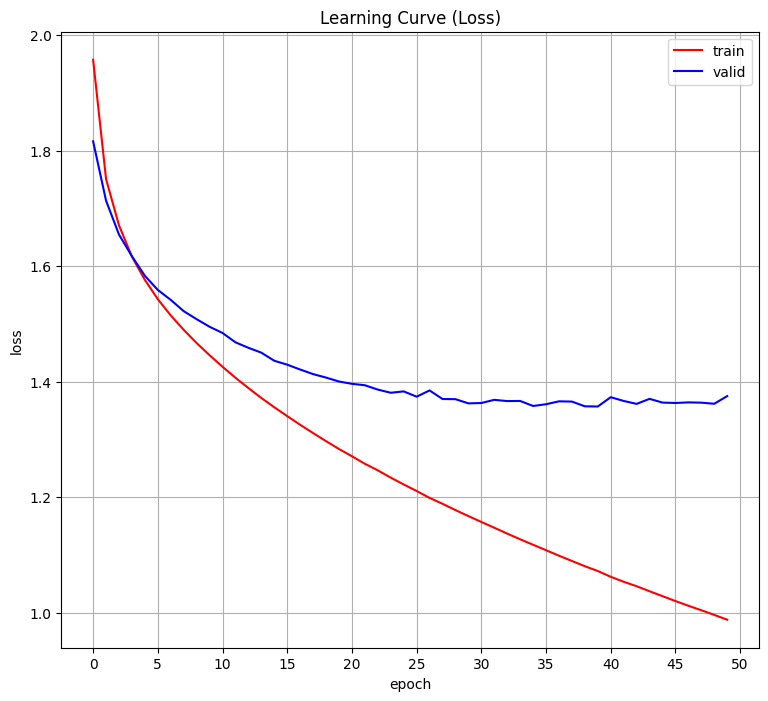

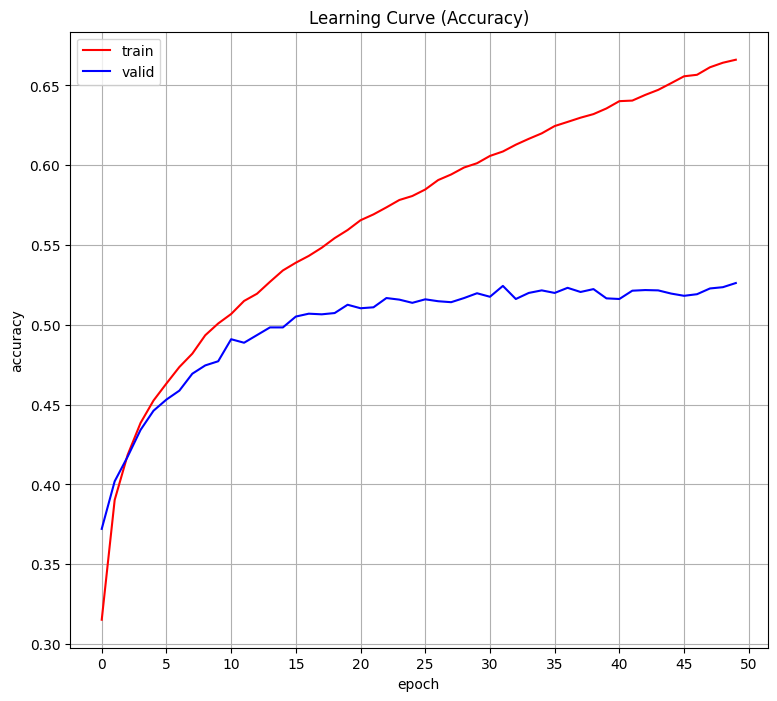

In [15]:
evaluate_history(history)
